# 03. Modeling & Evaluation

B1 종료 근접 36셀 → 정책 단위 학습 28 / 홀드아웃 8 → 외부 정책 그룹 4-fold CV → 내부 정책 그룹 3-fold로 하이퍼파라미터 선택 → 후보 고정 → 홀드아웃·B2·선택 B3 평가.

[검증 설계와 논문 비교 조건](../docs/analysis.md) · [실행 검증 기록](../docs/validation.md)


In [1]:
# ── 공통 설정 ──────────────────────────────────────────────
import sys
from pathlib import Path

# notebooks/ 에서 실행해도 프로젝트 루트의 src 패키지를 import 할 수 있도록 경로 추가
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 설치된 한글 폰트가 있으면 사용하고, 그림의 영문 표기는 기본 폰트로도 표시한다.
from matplotlib import font_manager
fonts = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in ("AppleGothic", "Malgun Gothic", "NanumGothic") if f in fonts), "DejaVu Sans")
sns.set_theme(style="whitegrid", font=font)
plt.rcParams["axes.unicode_minus"] = False

# 배치별 색상 (Day 1 산출물과 동일한 톤)
BATCH_COLOR = {"B1": "#2f6b9a", "B2": "#c77d2a", "B3": "#7f5aa6"}

from src.train import main

# 전체 파이프라인 실행 (CV 비교 → 최종 모델 선택 → 홀드아웃·B2·B3 평가 → results/*.csv 저장)
# out: train / holdout / cv / final / model / pred / table / detail
out = main()

         model          features target  cv_mape  cv_std  vs_best_ridge_%p  folds_improved
      Baseline                 -    raw    16.43    1.39              7.59               0
         Ridge                dQ    raw     8.84    2.33              0.00               0
         Ridge                dQ    log     8.96    2.07              0.12               1
         Ridge        policy_raw    raw    16.16    1.30              7.33               0
         Ridge        policy_raw    log    15.90    1.72              7.07               0
         Ridge    policy_derived    raw    16.77    1.13              7.93               0
         Ridge    policy_derived    log    16.81    1.00              7.97               0
         Ridge     dQ+policy_raw    raw    10.19    1.63              1.35               1
         Ridge     dQ+policy_raw    log     9.80    2.30              0.97               1
         Ridge dQ+policy_derived    raw    10.43    2.59              1.60               0


fold                                        0        1       2      3
check                      item                                      
EN 계수 (dQ+policy_raw, log) C1           0.000   -0.040   0.000  0.000
                           C2           0.006    0.009   0.000  0.000
                           SOC1        -0.000   -0.022   0.000  0.000
                           log_var_dQ  -0.047   -0.041  -0.061 -0.040
잔차 2차 계수 (최선 Ridge)        log_var_dQ -97.608  234.896  71.818  7.664



                        구분  MAPE (%)                           비고
        Train (Batch 1 CV)      8.84           4-fold 정책 그룹 CV 평균
  Valid (Batch 1 Hold-out)      7.79                정책 단위 홀드아웃 8셀
            Test (Batch 2)     27.87                   레이블 보유 39셀
         Gap (Train-Valid)     -1.05                 (+) : 과적합 의심
          Gap (Valid-Test)     20.09          (+) : 배치간 일반화 저하 의심
         Gap (Target-Test)     18.77            Target : 원논문 9.1%
            Test (Batch 3)     12.11                   레이블 보유 44셀
       Gap (Batch2-Batch3)    -15.77 Test 성능 간 비교 · (+) : B3에서 저하
Gap (Target-Test, Batch 3)      3.01        Batch 3 기준, 원논문 성능 비교

     batch                 subset  n  MAPE    MAE  over_%
B1 holdout                    all  8  7.79  51.66   62.50
B1 holdout         group=standard  8  7.79  51.66   62.50
B1 holdout           out_of_range  2  5.27  28.38  100.00
B1 holdout               in_range  6  8.63  59.43   50.00
B1 holdout               life<599  2  5.27  28.3

## 1. CV 모델 비교
채택 기준: 최선 Ridge 대비 MAPE 1%p 이상 감소 + 4개 중 3개 폴드 개선

In [2]:
# cv_mape: 4개 폴드 MAPE 평균 / vs_best_ridge_%p: 최선 Ridge 대비 차이 / folds_improved: 개선된 폴드 수
out["cv"].drop(columns="folds").round(2)

,model,features,target,cv_mape,cv_std,vs_best_ridge_%p,folds_improved
0,Baseline,-,raw,16.43,1.39,7.59,0
1,Ridge,dQ,raw,8.84,2.33,0.00,0
2,Ridge,dQ,log,8.96,2.07,0.12,1
3,Ridge,policy_raw,raw,16.16,1.30,7.33,0
4,Ridge,policy_raw,log,15.90,1.72,7.07,0
5,Ridge,policy_derived,raw,16.77,1.13,7.93,0
6,Ridge,policy_derived,log,16.81,1.00,7.97,0
7,Ridge,dQ+policy_raw,raw,10.19,1.63,1.35,1
8,Ridge,dQ+policy_raw,log,9.80,2.30,0.97,1
9,Ridge,dQ+policy_derived,raw,10.43,2.59,1.60,0


### 1-1. 변수 선택과 잔차 곡률

Elastic Net의 정책 단독·결합 입력을 모두 비교한다. 아래는 최선 Ridge 다변수 구성에서의 EN 계수다. 2차 잔차 계수는 소표본 탐색 진단이며 유의성 검정이나 트리의 필요성을 입증하지 않는다.


In [3]:
# value: EN 계수(표준화 입력 기준, log 타깃) / 잔차 2차 계수(부호 오차 % ~ log_var_dQ²)
out["diag"].pivot_table(index=["check", "item"], columns="fold", values="value").round(3)

fold                                        0        1       2      3
check                      item                                      
EN 계수 (dQ+policy_raw, log) C1           0.000   -0.040   0.000  0.000
                           C2           0.006    0.009   0.000  0.000
                           SOC1        -0.000   -0.022   0.000  0.000
                           log_var_dQ  -0.047   -0.041  -0.061 -0.040
잔차 2차 계수 (최선 Ridge)        log_var_dQ -97.608  234.896  71.818  7.664

## 2. 성능 리포트 (Format)

In [4]:
# 과제 Reporting format (Regression) — results/model_performance.csv 와 동일
out["table"]

,구분,MAPE (%),비고
0,Train (Batch 1 CV),8.84,4-fold 정책 그룹 CV 평균
1,Valid (Batch 1 Hold-out),7.79,정책 단위 홀드아웃 8셀
2,Test (Batch 2),27.87,레이블 보유 39셀
3,Gap (Train-Valid),-1.05,(+) : 과적합 의심
4,Gap (Valid-Test),20.09,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),18.77,Target : 원논문 9.1%
6,Test (Batch 3),12.11,레이블 보유 44셀
7,Gap (Batch2-Batch3),-15.77,Test 성능 간 비교 · (+) : B3에서 저하
8,"Gap (Target-Test, Batch 3)",3.01,"Batch 3 기준, 원논문 성능 비교"


## 3. B2·B3 세부 (실험집단 / 입력 범위)

In [5]:
# over_%: 과대 예측률 (수명을 실제보다 길게 예측한 셀 비율)
# in_range / out_of_range: 학습 28셀의 입력 범위 안·밖
out["detail"].round(2)

,batch,subset,n,MAPE,MAE,over_%
0,B1 holdout,all,8,7.79,51.66,62.50
1,B1 holdout,group=standard,8,7.79,51.66,62.50
2,B1 holdout,out_of_range,2,5.27,28.38,100.00
3,B1 holdout,in_range,6,8.63,59.43,50.00
4,B1 holdout,life<599,2,5.27,28.38,100.00
5,B1 holdout,policy=4.8C(80%)-4.8C,2,15.26,105.67,50.00
6,B1 holdout,policy=5.4C(80%)-5.4C,2,5.27,28.38,100.00
7,B1 holdout,policy=6C(60%)-3C,2,2.37,17.78,0.00
8,B1 holdout,policy=8C(25%)-3.6C,2,8.26,54.83,100.00
9,B2,all,39,27.87,139.34,92.31


## 4. 예측 vs 실제

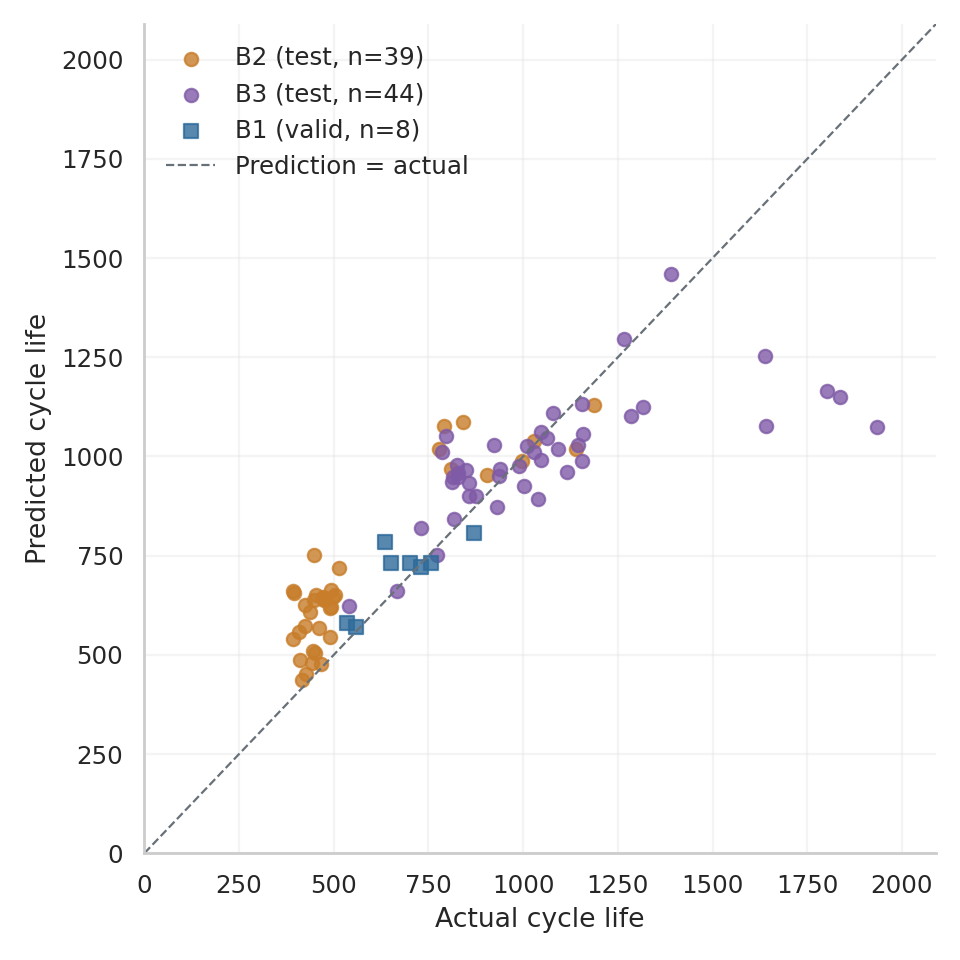

In [6]:
from IPython.display import Image, display

pred = out["pred"]
# CLI와 같은 실행에서 생성한 그림을 사용한다.
display(Image(filename=str(ROOT / "results" / "pred_vs_actual.png")))


## 5. 오류 분석
- 가장 크게 틀린 셀의 공통점, 원인 가설, 개선 방향

In [7]:
# 평가 대상 전체의 절대 백분율 오차 상위 10셀
pred.sort_values("ape_%", ascending=False)[
    ["cell_id", "batch", "group", "policy", "cycle_life", "pred", "ape_%", "log_var_dQ"]].head(10).round(1)


,cell_id,batch,group,policy,cycle_life,pred,ape_%,log_var_dQ
14,B2_c06,B2,standard,3.6C(9%)-5C,393.0,661.9,68.4,-3.5
26,B2_c18,B2,standard,5.2C(50%)-4.25C,449.0,751.9,67.5,-3.7
23,B2_c15,B2,standard,3.6C(9%)-5C,396.0,654.9,65.4,-3.5
10,B2_c02,B2,standard,5.2C(50%)-4.25C,424.0,626.4,47.7,-3.5
83,B3_c38,B3,newstructure,5C(67%)-4C-newstructure,1935.0,1074.3,44.5,-4.3
35,B2_c29,B2,standard,5.2C(58%)-4C,452.0,650.8,44.0,-3.5
19,B2_c11,B2,standard,5.2C(50%)-4.25C,449.0,639.2,42.4,-3.5
30,B2_c24,B2,standard,4.8C(80%)-4.8C,514.0,718.2,39.7,-3.6
34,B2_c28,B2,standard,4.8C(80%)-4.8C,437.0,607.7,39.1,-3.4
27,B2_c19,B2,standard,6C(60%)-3C,392.0,540.9,38.0,-3.3


### 5-1. 오차 방향 — 배치·실험집단별 평균 부호 오차
(+) = 수명을 길게 예측

In [8]:
test = pred[pred["split"] == "test"].assign(signed_err=lambda d: (d.pred - d.cycle_life) / d.cycle_life * 100)
test.groupby(["batch", "group"]).agg(n=("cell_id", "size"), signed_err_mean=("signed_err", "mean"),
                                     over_rate=("signed_err", lambda s: (s > 0).mean() * 100)).round(1)

n  signed_err_mean  over_rate
batch group                                       
B2    newstructure   9             11.7       66.7
      standard      30             31.6      100.0
B3    newstructure  44             -1.6       50.0

### 5-2. 같은 ΔQ, 다른 수명 — ΔQ ↔ 수명 관계의 배치 이동
B2 standard 셀은 ΔQ 값이 B1 학습 범위 안에 있어도 수명이 훨씬 짧다 → 모델이 B1의 관계를 그대로 적용해 과대 예측

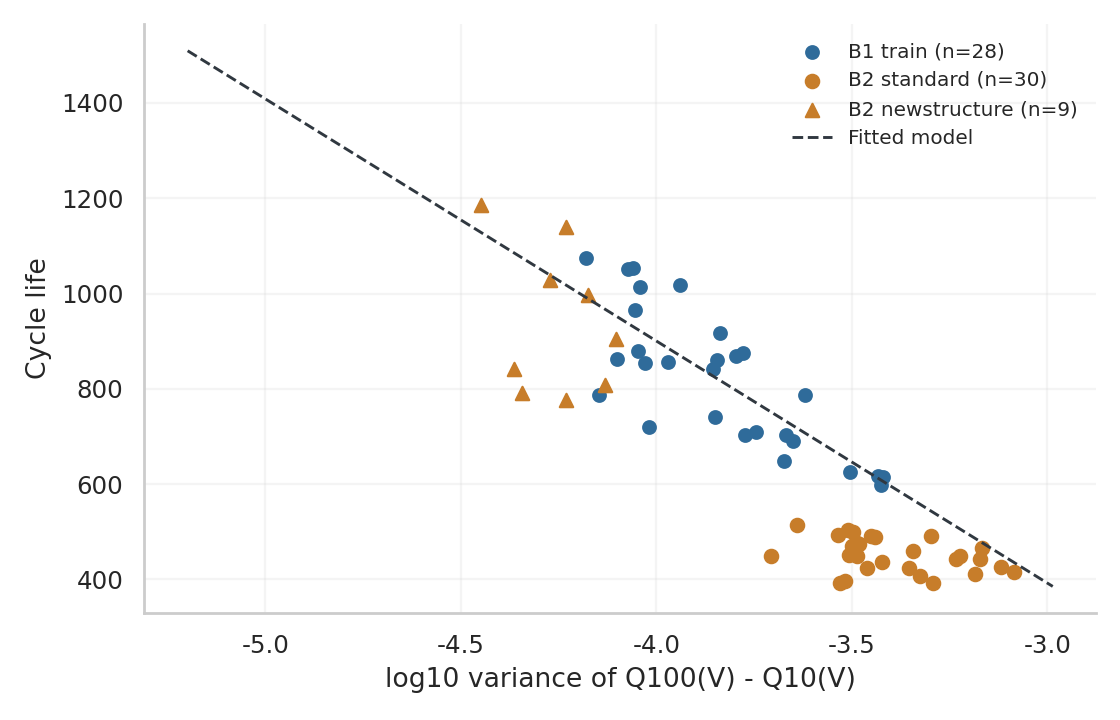

In [9]:
train = out["train"]
display(Image(filename=str(ROOT / "results" / "dq_shift_b1_b2.png")))


### 5-3. 같은 충전 정책의 배치 비교

정책을 고정해도 평균 수명이 다르다. 표본 수가 작으므로 로트·환경·측정 공백을 원인으로 확정할 수는 없다.


In [10]:
feat_all = pd.concat([out["train"], out["holdout"], test], ignore_index=True)
same = feat_all[feat_all.policy.isin(["6C(60%)-3C", "4.8C(80%)-4.8C"])]
same.groupby(["policy", "batch", "group"]).agg(
    n=("cell_id", "size"), life_mean=("cycle_life", "mean"), log_var_dQ=("log_var_dQ", "mean")).round(2)

n  life_mean  log_var_dQ
policy         batch group                             
4.8C(80%)-4.8C B1    standard  2      753.0       -3.79
               B2    standard  5      483.6       -3.50
6C(60%)-3C     B1    standard  2      744.0       -3.66
               B2    standard  2      400.0       -3.31

## 6. 성능 차이 해석과 ESS 의사결정

### 결과에서 배운 점

초기 용량 곡선만으로는 수명이 다른 셀을 구분하기 어려웠지만, 전압별 방전 곡선의 변화인 ΔQ에서는 수명과 연결된 신호를 찾을 수 있었다. 지금 용량이 비슷하다는 이유만으로 앞으로 쓸 수 있는 기간도 비슷하다고 판단하기는 어렵다는 점을 배웠다.

다만 B1에서 잘 맞았던 관계가 B2에서는 수명을 길게 예상했다. 같은 충전 방식을 사용한 셀도 배치별로 수명이 달랐으므로, 충전 조건과 생산 배치를 함께 살펴야 한다. 좋은 CV 점수를 얻은 뒤에도 새로운 배치에서 따로 검증하는 과정이 필요했다.

### ESS 운영에서 이 오류가 갖는 의미

ESS는 피크 시간이나 비상 상황에 필요한 에너지를 공급해야 한다. 수명을 길게 예상해 점검·교체를 늦추면 공급 계획에 차질이 생길 수 있고, 짧게 예상하면 아직 쓸 수 있는 셀을 일찍 교체하는 비용이 생긴다. 평균 오차와 함께 어느 방향으로 틀렸는지를 보는 것이 중요하다고 판단했다. 이런 운영상 영향은 결과에서 도출한 시사점이며 실제 공급 차질이나 비용을 측정한 것은 아니다.

지금 모델은 조건이 맞는 실험 데이터에서 먼저 점검할 셀을 추리는 보조 지표로 검토할 수 있다. 총 사이클 수를 예측했으므로 현재 잔여 수명이나 달력상 교체 날짜를 바로 알려주지는 않는다. 다음에는 새 생산 배치와 실제 사용 조건에서 검증하고, 특히 반복된 과대 예측을 줄일 수 있는지 먼저 확인하고 싶다.

### 비교할 때 남겨야 할 한계

- CV는 후보 선택에도 사용된 점수이며, 홀드아웃은 8셀의 단일 분할이다. 작은 음의 Gap으로 과적합을 배제하지 않는다.
- 논문 9.1%는 과제 지정 기준이다. 학습 셀 수·분할·입력·제외 기준이 달라 같은 조건의 재현 성능으로 해석하지 않는다.
- 여러 생산 배치의 독립 검증, 일관된 진단 기록과 예측 불확실성의 검증은 후속 과제다. 구체적인 근거와 다음 검증 순서는 [상세 분석](../docs/analysis.md#ess-활용-범위와-한계)에 정리했다.


In [11]:
from src.verify import verify
verify()


PASS: 정책 분리(홀드아웃·외부 CV·내부 CV), 후보 선택, 91셀 재학습 예측, 성능표·세부 지표·코드 해시 일치
